# 第 4 讲 Demo：传感器与坐标转换（无硬件仿真版）

本 Notebook 实现讲义第 4 讲「传感器与感知基础」的贯穿案例：**点击图像中的目标像素 → 反投影到相机坐标系 → 经外参变换到机器人 base 坐标系 → 生成可执行目标位姿**，并做三组误差扰动实验。

```text
pixel(u, v)
  ↓ 读取鲁棒深度 Z
point_camera(X, Y, Z)
  ↓ T_base_camera
point_base(x, y, z)
  ↓ 加安全偏移和姿态
target_pose_base
```

支持**两种数据源**（在下方单元用 `SOURCE` 切换）：

- `synthetic`：程序合成的 RGB + uint16 毫米深度图，有逐点真值，可对照验证（讲义 4.6.6 例子）。
- `tum`：**真实 TUM RGB-D fr1/desk 序列**（已按时间戳 associate 配对取一对图），真实相机内参 + 真实深度，教学效果更好，但无逐点真值。

无硬件版（讲义 4.10.3）不需要真机驱动与 ROS 2 运行时：用虚拟外参 `T_base_camera` 等价表达 TF 中的 `base_link → camera_optical_frame`。

## 运行前说明（建议使用隔离环境）

- **建议隔离环境运行**：先 `bash setup_env.sh`（默认 venv，`--conda` 用 conda），自动创建环境并注册 Jupyter kernel `lecture4-sensors`。
- 依赖：numpy / scipy / matplotlib / PyYAML / Pillow / jupyter（见 `requirements.txt` / `environment.yml`）。
- 请在**项目根目录**启动 Jupyter，保证 `make_sample_data.py`、`prepare_tum_data.py` 与 `data/`、`camera_info.yaml` 可被访问。
- TUM 真实数据由 `prepare_tum_data.py` 从序列中提取（`data/tum_rgb.png`、`data/tum_depth.png`、`data/tum_camera_info.yaml`）；合成数据由 `make_sample_data.py` 生成（`data/rgb.png`、`data/depth.npy`）。
- 用 matplotlib 3D 完成点云 / 坐标轴 / 目标点可视化（等价于讲义的 Open3D 步骤）。

In [1]:
import os
import sys
import json

import numpy as np
import yaml
import scipy
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  注册 3D 投影
from scipy.spatial.transform import Rotation

sys.path.insert(0, os.getcwd())

%matplotlib inline

print("numpy      ", np.__version__)
print("scipy      ", scipy.__version__)
print("matplotlib ", matplotlib.__version__)

numpy       2.2.6
scipy       1.15.3
matplotlib  3.10.9


## 数据源、相机内参与样例数据

- 像素 `(u, v)`：`u` 向右增大、`v` 向下增大；访问数组是 `image[v, u]`（行、列），与数学 `(u, v)` 相反（checklist 第 5 条）。
- 相机内参 `K`：`fx, fy`（像素焦距）、`cx, cy`（主点）。**内参与相机/分辨率绑定**，换相机必须重新读取（讲义 4.6.3）。
- 深度有 scale：合成数据是 uint16 毫米（`/1000` 得米）；TUM 是 16bit、`/5000` 得米。**忘记除以 scale 是经典错误**（讲义 4.6.4 / 4.10.5）。
- TUM 的 depth 图已配准到 RGB 平面（像素一一对应）；反投影深度图使用 **depth 相机内参**（`fx=fy=525.0, cx=319.5, cy=239.5`），RGB 内参（`517.3`）仅用于显示彩色图。

In [2]:
import PIL.Image as Image
from make_sample_data import save_sample_data

# ===== 选择数据源：'synthetic'（合成，有真值）或 'tum'（真实 RGB-D）=====
SOURCE = "tum"

if SOURCE == "synthetic":
    rgb_path = os.path.join("data", "rgb.png")
    depth_path = os.path.join("data", "depth.npy")
    if not (os.path.exists(rgb_path) and os.path.exists(depth_path)):
        print("data/ 缺失，现场合成样例数据 ...")
        save_sample_data("data")

    rgb = np.asarray(Image.open(rgb_path))
    depth_raw = np.load(depth_path).astype(np.int64)   # uint16 毫米
    depth_scale = 1000.0                               # 毫米 -> 米
    fx, fy, cx, cy = 600.0, 600.0, 320.0, 240.0        # 合成相机内参（讲义 4.6.3）
    click_uv = (420, 220)                              # 物块顶面中心
    point_camera_gt = np.array([0.10, -0.02, 0.60])    # 逐点真值（讲义 4.6.6）
    source_label = "合成样例（有真值）"

elif SOURCE == "tum":
    rgb = np.asarray(Image.open("data/tum_rgb.png"))
    depth_raw = np.asarray(Image.open("data/tum_depth.png")).astype(np.int64)  # 16bit
    depth_scale = 5000.0                               # /5000 = 米
    fx, fy, cx, cy = 525.0, 525.0, 319.5, 239.5        # fr1 depth 内参（反投影用）
    click_uv = (320, 240)                              # 图像中心（该点深度有效）
    point_camera_gt = None                             # 真实数据无逐点真值
    source_label = "TUM RGB-D fr1/desk（真实数据）"

else:
    raise ValueError("SOURCE 只能是 'synthetic' 或 'tum'")

# 4.10.3 步骤 1：加载并打印尺寸、dtype 和深度范围
print(f"数据源：{source_label}")
print("RGB    shape:", rgb.shape, " dtype:", rgb.dtype)
print("depth  shape:", depth_raw.shape, " dtype:", depth_raw.dtype)
print(f"深度 scale = {depth_scale}（原始值 / {depth_scale} = 米）")
valid = depth_raw[depth_raw > 0]
print(f"有效深度范围: {valid.min()/depth_scale:.2f} ~ {valid.max()/depth_scale:.2f} m，无效像素(==0): {(depth_raw == 0).sum()}")
print(f"反投影内参: fx={fx}, fy={fy}, cx={cx}, cy={cy}")

数据源：TUM RGB-D fr1/desk（真实数据）
RGB    shape: (480, 640, 3)  dtype: uint8
depth  shape: (480, 640)  dtype: int64
深度 scale = 5000.0（原始值 / 5000.0 = 米）


有效深度范围: 0.47 ~ 1.48 m，无效像素(==0): 60426
反投影内参: fx=525.0, fy=525.0, cx=319.5, cy=239.5


/tmp/ipykernel_3458/3271223096.py:9: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3458/3271223096.py:9: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3458/3271223096.py:9: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3458/3271223096.py:9: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3458/3271223096.py:9: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3458/3271223096.py:9: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/root/lecture4-sensors-coordinates/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/lecture4-sensors-coordinates/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/lecture4-sensors-coordinates/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/lecture4-sensors-coordinates/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/lecture4-sensors-coordinates/.venv/lib/python3.10/

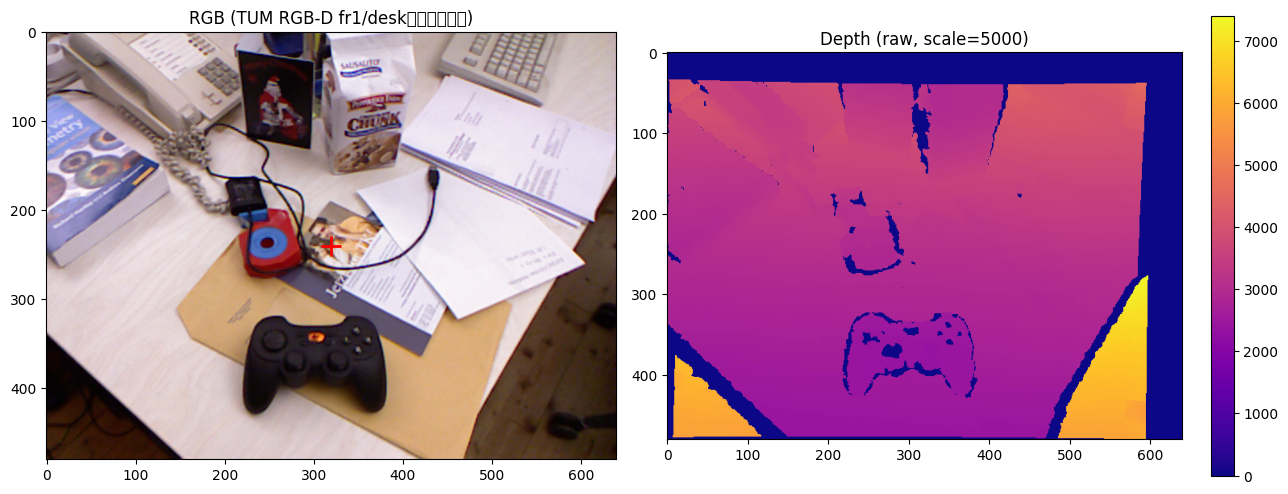

In [3]:
# 显示 RGB 与深度图，并在目标像素上做标记
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(rgb)
axes[0].set_title(f"RGB ({source_label})")
axes[0].plot(click_uv[0], click_uv[1], "r+", markersize=14, markeredgewidth=2)
im = axes[1].imshow(depth_raw, cmap="plasma")
axes[1].set_title(f"Depth (raw, scale={depth_scale:.0f})")
fig.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()

## 4.6.6　外参与齐次变换

约定 `T_A_B` 把 B 系中的量转换到 A 系。`T_base_camera` 把 `camera_optical_frame` 中的点转到 `base_link`。

- `base_link`：x 向前、y 向左、z 向上；`camera_optical_frame`：z 向前、x 向右、y 向下。
- 忽略相机倾角时，optical → base 的旋转为（讲义 4.6.6）：

```text
R_base_optical = [[ 0,  0,  1],
                  [-1,  0,  0],
                  [ 0, -1,  0]]
```

- 相机光心安装在 base 前方 0.20 m、左侧 0.05 m、上方 0.40 m，即 `t = [0.20, 0.05, 0.40]`。

> 无硬件版里这个外参是**虚拟设定**的（真实数据集的 RGB-D 没有「机器人 base」参考系）。接真机时需要替换成真实数据。

In [4]:
R_base_optical = np.array([[0.0, 0.0, 1.0],
                           [-1.0, 0.0, 0.0],
                           [0.0, -1.0, 0.0]])
t_base_optical = np.array([0.20, 0.05, 0.40])

T_base_camera = np.eye(4)
T_base_camera[:3, :3] = R_base_optical
T_base_camera[:3, 3] = t_base_optical

print("R_base_optical =\n", R_base_optical)
print("t_base_optical =", t_base_optical)
print("T_base_camera  =\n", T_base_camera)

R_base_optical =
 [[ 0.  0.  1.]
 [-1.  0.  0.]
 [ 0. -1.  0.]]
t_base_optical = [0.2  0.05 0.4 ]
T_base_camera  =
 [[ 0.    0.    1.    0.2 ]
 [-1.    0.    0.    0.05]
 [ 0.   -1.    0.    0.4 ]
 [ 0.    0.    0.    1.  ]]


## 4.6.5　RGB-D 反投影

```text
X = (u - cx) * Z / fx
Y = (v - cy) * Z / fy
P_c = [X, Y, Z]
```

深度读取**不要只信单个像素**：在邻域内剔除 `0` / NaN / Inf，取中位数；无有效深度时返回失败，而不是输出零坐标。

In [5]:
def deproject(u, v, Z):
    """像素 (u, v) 与轴向深度 Z（米）反投影到 camera 系三维点。"""
    X = (u - cx) * Z / fx
    Y = (v - cy) * Z / fy
    return np.array([X, Y, Z], dtype=float)


def robust_depth(depth_raw, u, v, depth_scale, radius=3):
    """在 (u, v) 邻域内过滤无效深度取中位数，返回 (depth_m, valid_count)。"""
    h, w = depth_raw.shape
    u0, u1 = max(0, u - radius), min(w, u + radius + 1)
    v0, v1 = max(0, v - radius), min(h, v + radius + 1)
    patch = depth_raw[v0:v1, u0:u1].astype(np.float64)
    valid = patch[patch > 0]                       # 剔除 0（无效深度）
    if valid.size == 0:
        return None, 0
    return float(np.median(valid)) / depth_scale, int(valid.size)   # 转米


# 4.10.3 步骤 3/4/5：选择像素 -> 邻域中位数 -> 反投影
Z, n_valid = robust_depth(depth_raw, click_uv[0], click_uv[1], depth_scale)
print(f"点击像素 {click_uv}，邻域有效深度样本数 = {n_valid}，中位深度 Z = {Z:.4f} m")

point_camera = deproject(click_uv[0], click_uv[1], Z)
print("point_camera =", np.round(point_camera, 4), "m")

if point_camera_gt is not None:
    print("真值对照     =", np.round(point_camera_gt, 4), "m")
    print("反投影误差   =", np.round(np.abs(point_camera - point_camera_gt), 6), "m")
else:
    print("（真实数据无逐点真值，验收看深度 scale / 内参 / 反投影量级是否合理）")

点击像素 (320, 240)，邻域有效深度样本数 = 49，中位深度 Z = 0.6272 m
point_camera = [6.000e-04 6.000e-04 6.272e-01] m
（真实数据无逐点真值，验收看深度 scale / 内参 / 反投影量级是否合理）


## 4.6.6　从 camera 到 base

```text
p_base = T_base_camera · p_camera   （点用齐次坐标 [X, Y, Z, 1]）
```

相机正前方目标 `point_camera` 转到 base 后应落在机器人前方，而不是地下、背后或远高于相机。

In [6]:
def apply_transform(T, p):
    """把 3D 点 p 经 4x4 齐次变换 T 变换（列向量约定，p 末尾补 1）。"""
    ph = np.append(np.asarray(p, dtype=float), 1.0)
    return (T @ ph)[:3]


point_base = apply_transform(T_base_camera, point_camera)
print("point_base =", np.round(point_base, 4), "m")

if point_camera_gt is not None:
    point_base_gt = R_base_optical @ point_camera_gt + t_base_optical
    print("真值对照   =", np.round(point_base_gt, 4), "m")
    print("变换误差   =", np.round(np.abs(point_base - point_base_gt), 6), "m")

point_base = [0.8272 0.0494 0.3994] m


## 4.10.3 步骤 7　显示点云、坐标轴与目标点

从深度图反投影出整幅点云并变换到 base 系，叠加 base / camera 坐标轴与目标点。坐标轴三色约定：x 红、y 绿、z 蓝。

/tmp/ipykernel_3458/1024911656.py:40: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3458/1024911656.py:40: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3458/1024911656.py:40: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3458/1024911656.py:40: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3458/1024911656.py:40: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3458/1024911656.py:40: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3458/1024911656.py:41: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS

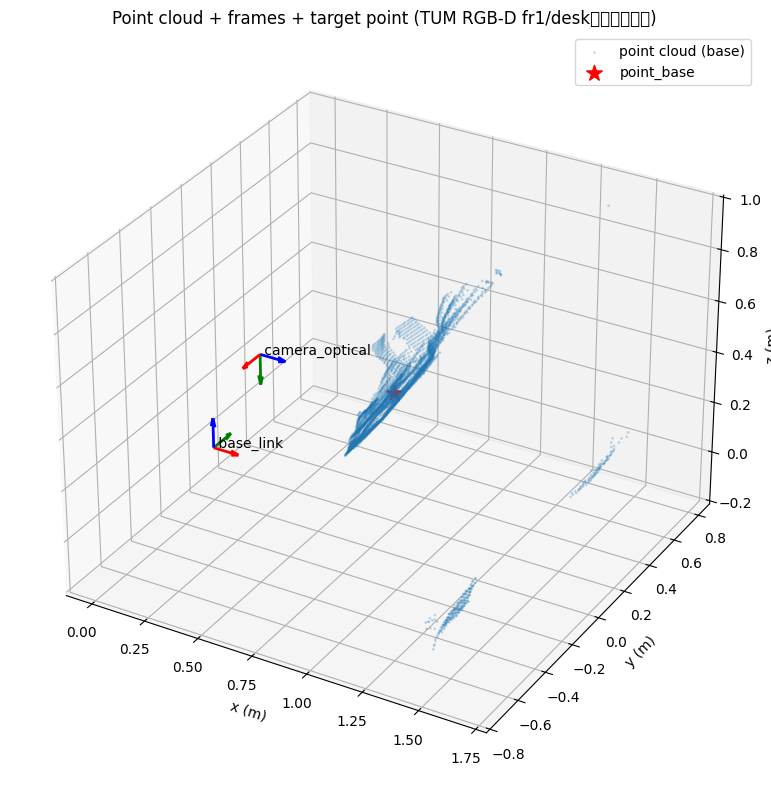

In [7]:
def build_pointcloud_base(depth_raw, depth_scale, step=8):
    """深度图反投影 -> camera 系点云 -> base 系点云（每 step 像素采样）。"""
    h, w = depth_raw.shape
    ys, xs = np.mgrid[0:h:step, 0:w:step]
    Zs = depth_raw[ys, xs].astype(np.float64) / depth_scale
    ok = Zs > 0
    Xs = (xs[ok] - cx) * Zs[ok] / fx
    Ys = (ys[ok] - cy) * Zs[ok] / fy
    pc_cam = np.stack([Xs, Ys, Zs[ok]], axis=1)
    pc_base = np.array([apply_transform(T_base_camera, p) for p in pc_cam])
    return pc_base


def draw_frame(ax, R, t, length=0.12, label=""):
    """在 3D 轴绘制一个坐标系：原点 t，三轴方向为 R 的列（x红/y绿/z蓝）。"""
    o = np.asarray(t, dtype=float)
    for i, c in enumerate(["red", "green", "blue"]):
        ax.quiver(o[0], o[1], o[2],
                  R[0, i], R[1, i], R[2, i],
                  length=length, color=c, linewidth=2)
    if label:
        ax.text(o[0], o[1], o[2], f" {label}", color="black")


pc_base = build_pointcloud_base(depth_raw, depth_scale, step=8)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(pc_base[:, 0], pc_base[:, 1], pc_base[:, 2],
           s=1, c="tab:blue", alpha=0.2, label="point cloud (base)")

draw_frame(ax, np.eye(3), [0, 0, 0], label="base_link")
draw_frame(ax, R_base_optical, t_base_optical, label="camera_optical")

ax.scatter(*point_base, s=140, c="red", marker="*", label="point_base")

ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.set_zlabel("z (m)")
ax.set_title(f"Point cloud + frames + target point ")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("output/step7_visualization.png", dpi=120)
plt.show()

## 4.10.3 步骤 8 + 4.10.5　扰动实验 1：深度 scale 错误

- **对照**：深度增加 10 mm 只会让目标点沿视线方向平移约 10 mm。
- **经典错误**：忘记除以 `depth_scale`，把原始整数值当米。合成数据差 1000 倍、TUM 差 5000 倍，目标点飞到极远。

In [8]:
# (a) 正确：深度 +10 mm（4.10.3 步骤 8）
Z_plus = Z + 0.010
point_camera_plus = deproject(click_uv[0], click_uv[1], Z_plus)
point_base_plus = apply_transform(T_base_camera, point_camera_plus)
delta_plus = point_base_plus - point_base
print("深度 +10mm -> point_base 变化 =", np.round(delta_plus, 4),
      "m，位移范数 =", round(float(np.linalg.norm(delta_plus)), 5), "m")

# (b) 错误：忘记除以 depth_scale，把原始整数值当米
Z_wrong = Z * depth_scale               # 还原成原始整数值，错误地直接当米
point_camera_wrong = deproject(click_uv[0], click_uv[1], Z_wrong)
point_base_wrong = apply_transform(T_base_camera, point_camera_wrong)
print("\n忘记 /scale -> point_camera =", np.round(point_camera_wrong, 2), "m")
print("忘记 /scale -> point_base   =", np.round(point_base_wrong, 2), "m  <- 飞到极远")

深度 +10mm -> point_base 变化 = [ 0.01 -0.   -0.  ] m，位移范数 = 0.01 m

忘记 /scale -> point_camera = [2.990e+00 2.990e+00 3.136e+03] m
忘记 /scale -> point_base   = [ 3.1362e+03 -2.9400e+00 -2.5900e+00] m  <- 飞到极远


## 4.10.3 步骤 9　扰动实验 2：外参旋转扰动 1°

给外参 `R_base_optical` 再乘一个绕 base z 轴 1° 的小旋转，模拟安装角度误差。旋转误差引起的位移与目标距离成正比：**远距离目标误差被放大**。

In [9]:
delta_R = Rotation.from_euler("z", np.deg2rad(1.0)).as_matrix()
R_perturbed = delta_R @ R_base_optical
T_perturbed = T_base_camera.copy()
T_perturbed[:3, :3] = R_perturbed

point_base_pert = apply_transform(T_perturbed, point_camera)
err_near = np.linalg.norm(point_base_pert - point_base)

# 远距离目标（同一像素、更大深度）验证误差放大
Z_far = 3.0
point_camera_far = deproject(click_uv[0], click_uv[1], Z_far)
p_far_true = apply_transform(T_base_camera, point_camera_far)
p_far_pert = apply_transform(T_perturbed, point_camera_far)
err_far = np.linalg.norm(p_far_pert - p_far_true)

print("外参绕 z 旋转 1° 后：")
print("  近点 (Z=%.2fm) 目标位移 = %.5f m" % (Z, err_near))
print("  远点 (Z=3.0m)  目标位移 =", round(float(err_far), 5), "m  <- 误差被距离放大")

外参绕 z 旋转 1° 后：
  近点 (Z=0.63m) 目标位移 = 0.01095 m
  远点 (Z=3.0m)  目标位移 = 0.05236 m  <- 误差被距离放大


## 4.10.3 步骤 10 + 4.10.5　扰动实验 3：外参方向写反

经典错误二：把 `T_camera_base`（`T_base_camera` 的逆）当成 `T_base_camera`。数值上仍是合法变换，但目标点落到机器人背后 / 地下（z 为负）。

In [10]:
T_camera_base = np.linalg.inv(T_base_camera)   # 错误地用了逆矩阵
point_base_wrong2 = apply_transform(T_camera_base, point_camera)

print("用逆矩阵 T_camera_base 当 T_base_camera：")
print("  point_base =", np.round(point_base_wrong2, 4), "m")
print("  z 分量 =", round(float(point_base_wrong2[2]), 4), "m（负值 -> 落到地下）")

用逆矩阵 T_camera_base 当 T_base_camera：
  point_base = [ 0.0494 -0.2272 -0.1994] m
  z 分量 = -0.1994 m（负值 -> 落到地下）


## 4.6.7　从三维点到可执行目标

`point_base` 只回答「目标点在哪里」，机械臂末端还需要完整位姿 `[x, y, z, qx, qy, qz, qw]`（位置 + 单位四元数姿态）。

1. 到达演示在目标上方加安全偏移，例如 `delta_p_safe = [0, 0, 0.05]`。
2. 姿态来自任务固定方向；桌面到达用「夹爪朝下」（末端 z 轴指向 `-z_base`）。
3. 四元数顺序是 **x, y, z, w**。

In [11]:
safe_offset = np.array([0.0, 0.0, 0.05])
p_pre = point_base + safe_offset

# 夹爪朝下：绕 base x 轴旋转 180°（R 的 z 列 = [0, 0, -1]）
R_gripper_down = Rotation.from_euler("x", np.pi).as_matrix()
q = Rotation.from_matrix(R_gripper_down).as_quat()          # 返回 [x, y, z, w]
target_pose_base = np.concatenate([p_pre, q])

print("p_pre (目标上方 5cm) =", np.round(p_pre, 4), "m")
print("R_gripper_down =\n", R_gripper_down)
print("四元数 [x,y,z,w] =", np.round(q, 4))
print("target_pose_base =", np.round(target_pose_base, 4))

p_pre (目标上方 5cm) = [0.8272 0.0494 0.4494] m
R_gripper_down =
 [[ 1.0000000e+00  0.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00 -1.0000000e+00 -1.2246468e-16]
 [ 0.0000000e+00  1.2246468e-16 -1.0000000e+00]]
四元数 [x,y,z,w] = [1. 0. 0. 0.]
target_pose_base = [0.8272 0.0494 0.4494 1.     0.     0.     0.    ]


## 4.10.4 验收 与 4.10.5 失败复盘

验收不是「代码不报错」，而是输出的点、frame、单位、时间和误差**均可解释**。下面汇总本链路各环节数值并保存到 `output/results.json`。

In [12]:
results = {
    "source": SOURCE,
    "click_pixel": list(click_uv),
    "depth_scale": float(depth_scale),
    "depth_m": float(Z),
    "depth_raw_median": float(Z * depth_scale),
    "intrinsics": {"fx": fx, "fy": fy, "cx": cx, "cy": cy},
    "point_camera": np.round(point_camera, 6).tolist(),
    "point_base": np.round(point_base, 6).tolist(),
    "target_pose_base": np.round(target_pose_base, 6).tolist(),
    "depth_plus10mm_delta_m": np.round(delta_plus, 6).tolist(),
    "forgot_scale_point_base": np.round(point_base_wrong, 3).tolist(),
    "rotation_1deg_near_err_m": round(float(err_near), 6),
    "rotation_1deg_far_err_m": round(float(err_far), 6),
    "inverse_extrinsic_point_base": np.round(point_base_wrong2, 4).tolist(),
}

if point_camera_gt is not None:
    results["point_camera_gt"] = np.round(point_camera_gt, 6).tolist()
    results["point_base_gt"] = np.round(point_base_gt, 6).tolist()
    results["reprojection_error_m"] = float(np.linalg.norm(point_camera - point_camera_gt))
    results["transform_error_m"] = float(np.linalg.norm(point_base - point_base_gt))

os.makedirs("output", exist_ok=True)
with open("output/results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print(json.dumps(results, ensure_ascii=False, indent=2))

{
  "source": "tum",
  "click_pixel": [
    320,
    240
  ],
  "depth_scale": 5000.0,
  "depth_m": 0.6272,
  "depth_raw_median": 3136.0,
  "intrinsics": {
    "fx": 525.0,
    "fy": 525.0,
    "cx": 319.5,
    "cy": 239.5
  },
  "point_camera": [
    0.000597,
    0.000597,
    0.6272
  ],
  "point_base": [
    0.8272,
    0.049403,
    0.399403
  ],
  "target_pose_base": [
    0.8272,
    0.049403,
    0.449403,
    1.0,
    0.0,
    0.0,
    0.0
  ],
  "depth_plus10mm_delta_m": [
    0.01,
    -1e-05,
    -1e-05
  ],
  "forgot_scale_point_base": [
    3136.2,
    -2.937,
    -2.587
  ],
  "rotation_1deg_near_err_m": 0.010947,
  "rotation_1deg_far_err_m": 0.052359,
  "inverse_extrinsic_point_base": [
    0.0494,
    -0.2272,
    -0.1994
  ]
}


## 可选：交互式点击目标像素

若在支持交互后端的 Jupyter 中运行，可取消下面单元注释，用鼠标在 RGB 图上点击选取 `(u, v)`，替换默认的 `click_uv`（需安装 `ipympl`）。将此单元格放在第二个单元格后。

In [13]:
# %matplotlib widget   # 交互后端（可选，需 ipympl）
# fig, ax = plt.subplots()
# ax.imshow(rgb)
# pts = plt.ginput(1, timeout=-1)
# click_uv = (int(round(pts[0][0])), int(round(pts[0][1])))
# print("你点击的像素：", click_uv)
# plt.close(fig)